## Support dashboard - prosjektoppgave PY1010
Du skal her utføre diverse analyser av data som er loggført for supportavdelingen ved 
telefonselskapet MORSE. Enhver kundehenvendelse til MORSE blir loggført i en xlsx-fil og du 
skal i dette prosjektet jobbe med dataloggen for uke 24. Filen ‘support_uke_24.xlsx’ finner 
du sammen med prosjektoppgaven i Canvas under menyen Oppgaver -> Prosjektoppgaven, 
og filen er organisert på følgende måte

Kolonne 1: Ukedag henvendelsen fant sted
Kolonne 2: Klokkeslett kunden tok kontakt med supportavdelingen
Kolonne 3: Samtalens varighet
Kolonne 4: Kundens tilfredshet (skala fra 1-10 hvor 1 indikerer svært misfornøyd og 10 
indikerer svært fornøyd). 
Merk: kolonne 4 er ikke komplett da mange kunder unnlater å gi tilbakemelding på sin 
tilfredshet.

Selv om oppgaven er individuell, kan du selvsagt diskutere med kollegaer og søke hjelp fra 
våre studentassistenter underveis.


## Del A 
Skriv et program som leser inn filen ‘support_uke_24.xlsx’ og lagrer data fra kolonne 1 
i en array med variablenavn ‘u_dag’, dataen i kolonne 2 lagres i arrayen ‘kl_slett’, data i 
kolonne 3 lagres i arrayen ‘varighet’ og dataen i kolonne 4 lagres i arrayen ‘score’. Merk: 
filen ‘support_uke_24.xlsx’ må ligge i samme mappe som Python-programmet ditt.

In [24]:
## Del A

import pandas as pd
import numpy as np

filnavn = "support_uke_24.xlsx"

data = pd.read_excel(filnavn)

#print(data)

u_dag = data["Ukedag"].values
kl_slett = data["Klokkeslett"].values
varighet = data["Varighet"].values
score = data["Tilfredshet"].values

#print(u_dag)
#print(" ")
#print(kl_slett)
#print(" ")
#print(varighet)
#print(" ")
#print(score)



## Del B
Skriv et program som finner antall henvendelser for hver de 5 ukedagene. Resultatet 
visualiseres ved bruk av et søylediagram (stolpediagram).

<function matplotlib.pyplot.show(close=None, block=None)>

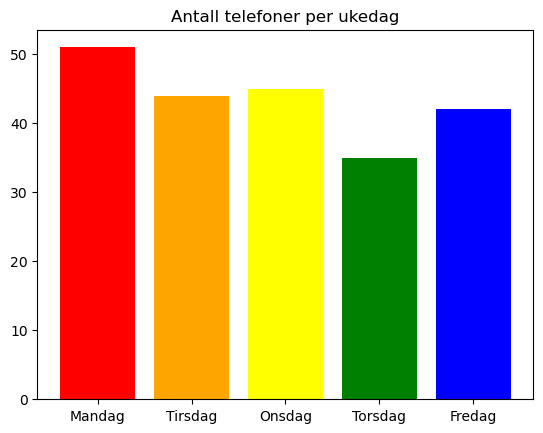

In [25]:
## Del B 

import numpy as np
import matplotlib.pyplot as plt

ukedager = ["Mandag", "Tirsdag", "Onsdag", "Torsdag", "Fredag"]
verdier = np.zeros(5)
indeks = 0

for elm in ukedager:   ## for hvert element i arrayen ukedager
    
    def antall_dag(u_dag1):  ##antall av en bestemt ukedag i denne iterasjonen
        antall = 0
        
        for dag in u_dag1:

           if dag == ukedager[indeks]:    ## skal søke på den ukedagen (verdien i arrayen ukedager med nåværende indeks)
               antall += 1

        return antall

    den_dagen = antall_dag(u_dag)
    verdier[indeks] = den_dagen

   #print("Det er", den_dagen, "av ukedagen", ukedager[indeks], "i lista.")
    
    indeks += 1

#print("Verdiene i en liste er:", verdier)

plt.bar(ukedager, verdier, color = ["red", "orange", "yellow", "green","blue"])
plt.title("Antall telefoner per ukedag")
plt.show


## Del C
Skriv et program som finner minste og lengste samtaletid som er loggført for uke 24. 
Svaret skrives til skjerm med informativ tekst.

In [26]:
## Del C

minste_tid = min(varighet)
#print(minste_samtaletid)

indeks_minste_tid = np.where(varighet == minste_tid)

#print(indeks_minste_tid)

lengste_tid = max (varighet)
#print(lengste_tid)

indeks_lengste_tid = np.where(varighet == lengste_tid)[0]
#print(indeks_lengste_tid)

print(" ")
print("Minste samtaletid var", minste_tid, "og inntraff på", u_dag[indeks_minste_tid][0], "klokken", kl_slett[indeks_minste_tid][0])
print(" ")
print("Lengste samtaletid var", lengste_tid, "og inntraff på", u_dag[indeks_lengste_tid][0], "klokken", kl_slett[indeks_lengste_tid][0])
print(" ")

 
Minste samtaletid var 00:00:59 og inntraff på Tirsdag klokken 08:39:50
 
Lengste samtaletid var 00:11:28 og inntraff på Fredag klokken 10:16:01
 


## Del D
KREVENDE: Skriv et program som regner ut gjennomsnittlig samtaletid basert på alle 
henvendelser i uke 24.

In [27]:
## Del D

indeks = 0
antall_elementer = len(varighet)
varighet_sekunder=np.zeros(antall_elementer)
#print(varighet_sekunder)

for elm in varighet:

    time, minutt, sekund = varighet[indeks].split(":")
    #print(time, minutt, sekund)
    #print(int(time)*3600)
    
    antall_sekunder= int(time)*3600 + int(minutt)*60 + int(sekund)
    #print(antall_sekunder)

    varighet_sekunder[indeks] = antall_sekunder

    indeks += 1

#print(varighet_sekunder)

gjennomsnitt = sum(varighet_sekunder) / len(varighet_sekunder)

timer, rest_timer = divmod (gjennomsnitt, 3600)
minutter, rest_minutter = divmod (rest_timer, 60)
sekunder = rest_minutter
#print(timer, minutter, sekunder)

print(" ")
print(round(gjennomsnitt,2), "er gjennomsnittlig samtaletid i sekunder som tilsvarer", timer, "timer", minutter, "minutter", round(sekunder,0), "sekunder")
print(" ")

 
400.01 er gjennomsnittlig samtaletid i sekunder som tilsvarer 0.0 timer 6.0 minutter 40.0 sekunder
 


## Del E
Supportvaktene i MORSE er delt inn i 2-timers bolker: kl 08-10, kl 10-12, kl 12-14 og kl 
14-16. Skriv et program som finner det totale antall henvendelser supportavdelingen mottok
for hver av tidsrommene 08-10, 10-12, 12-14 og 14-16 for uke 24. Resultatet visualiseres ved 
bruk av et sektordiagram (kakediagram)

<function matplotlib.pyplot.show(close=None, block=None)>

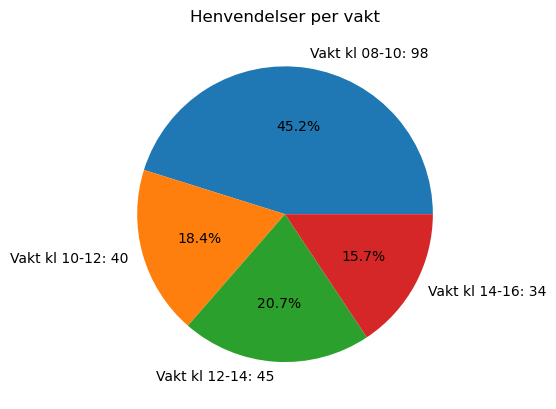

In [28]:
## Del E

vakt1 = 0
vakt2 = 0
vakt3 = 0
vakt4 = 0
indeks=0

#print(kl_slett)
for elm in kl_slett:
    time, minutt, sekund = kl_slett[indeks].split(":")
    #print(time)
    if 8 <= int(time) < 10:
        vakt1 += 1
    elif 10 <= int(time) < 12:
        vakt2 += 1
    elif 12 <= int(time) < 14:
        vakt3 += 1
    else:
        vakt4 +=1
    
    indeks += 1

arr_vakt=np.array([vakt1, vakt2, vakt3, vakt4])
vakt_pct= arr_vakt/sum(arr_vakt)

#print(arr_vakt)
#print(vakt_pct)

my_labels= ["Vakt kl 08-10: " + str(arr_vakt[0]), 
            "Vakt kl 10-12: " + str(arr_vakt[1]), 
            "Vakt kl 12-14: " + str(arr_vakt[2]), 
            "Vakt kl 14-16: " + str(arr_vakt[3])
           ]
values=[vakt1, vakt2, vakt3, vakt4]

plt.pie(
    values, 
    labels=my_labels,
    autopct = "%.1f%%"
)
plt.title("Henvendelser per vakt")
plt.show


## Del F
Kundens tilfredshet loggføres som tall fra 1-10 hvor 1 indikerer svært misfornøyd og 
10 indikerer svært fornøyd. Disse tilbakemeldingene skal så overføres til NPS-systemet (Net 
Promoter Score). 
NPS-systemet er konstruert på følgende måte:
Score 1-6 oppfattes som at kunden er negativ (vil trolig ikke anbefale MORSE til andre).
Score 7-8 oppfattes som et nøytralt svar.
Score 9-10 oppfattes som at kunden er positiv (vil trolig anbefale MORSE til andre).
Supportavdelingens NPS beregnes som et tall, prosentandelen positive kunder minus 
prosentandelen negative kunder. Ved en formel kan dette gis slik:
NPS = % positive kunder - % negative kunder
Et eksempel på utregning av NPS er gitt i figuren under.

https://www.blueprnt.com/2018/09/17/net-promoter-score/

Lag et program som regner ut supportavdelings NPS og skriver svaret til skjerm. Merk: 
Kunder som ikke har gitt tilbakemelding på tilfredshet, skal utelates fra utregningene. 

In [30]:
## Del F

antall_neg = 0
antall_ntr = 0
antall_pos = 0

indeks = 0

for svar in score:
    try:
        x = int(svar)  ## konverterer svar til et heltall (det går ikke med mindre svar allerede er et tall)
    except ValueError:
        continue
        
    if x <= 6:
        antall_neg += 1
    elif x > 6 and x <= 8:
        antall_ntr += 1
    else:
        antall_pos += 1

#print(antall_neg, antall_ntr, antall_pos)

antall_svar = antall_neg + antall_ntr + antall_pos  
#print(antall_svar)

pct_pos = round(((antall_pos/antall_svar)*100),2)
pct_neg = round(((antall_neg/antall_svar)*100),2)

#print(pct_pos)
#print(pct_neg)

nps = pct_pos - pct_neg

print(" ")
print("Supportavdelingens NPS er", nps, "%.")
print(" ")

 
Supportavdelingens NPS er 41.86 %.
 
